In [8]:
import numpy as np
from tensorflow.keras import layers, models, callbacks

In [ ]:
X_train = np.load("../datasets/normalized/norm_training_set.npy")
X_test = np.load("../datasets/normalized/norm_testing_set.npy")

(13583, 64, 32, 1)


In [10]:
inputs = layers.Input(shape=(64,32,1))

x = layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu')(x)
x = layers.UpSampling2D(2)(x)

output = layers.Conv2D(filters=1, kernel_size=(3,3), padding='same', activation='sigmoid')(x)

model = models.Model(inputs, output)

model.summary()
model.compile(optimizer="adam", loss="mse")

callback = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
model.fit(x=X_train, y=X_train, batch_size=32, epochs=200, validation_split=0.2, callbacks=[callback])
#np.load("../datasets/normalized/norm_training_set.npy")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 8, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 2/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 3/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 4/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 5/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0010 - val_loss: 9.9041e-04
Epoch 6/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9.4118e-04 - val_loss: 8.7254e-04
Epoch 7/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 8.4828e-04 - val_loss: 8.0679e-04
Epoch 8/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 7.5951e-04 - val_loss: 7.1506e-04
Epoch 9/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 7.0324e-04 - val_loss: 6.7003e-04
Epoch 10/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.6325e-04 - val_loss: 6.2924e-04
Epoch 11/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.3066e-04 -

In [11]:
from pathlib import Path

output_dir = Path('../models')
output_dir.mkdir(parents=True, exist_ok=True)
model.save(output_dir/'autoencoder.keras')

In [12]:
model = models.load_model("../models/autoencoder.keras")

train_predict = model.predict(x=X_train)
test_predict = model.predict(x=X_test)

train_loss = np.mean(np.square(X_train - train_predict), axis=(1,2,3))
test_loss = np.mean(np.square(X_test - test_predict), axis=(1,2,3))

425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


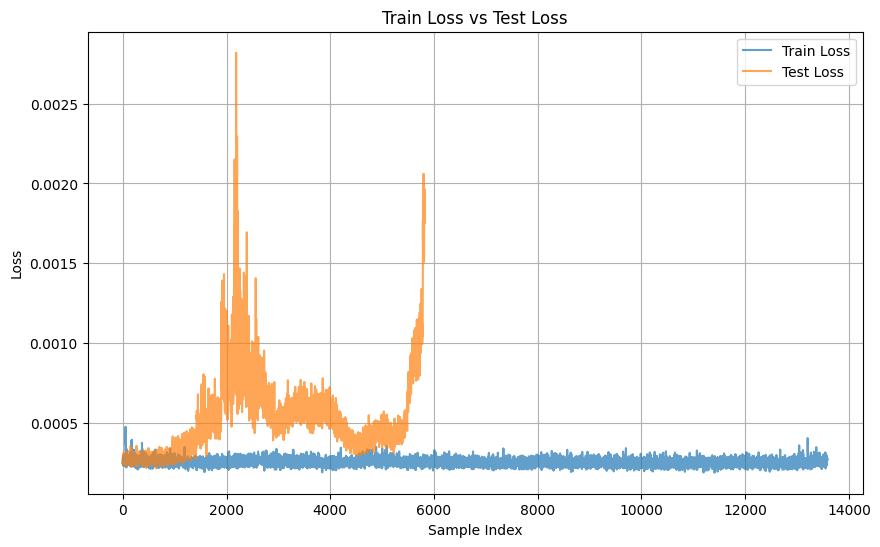

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss', alpha=0.7)
plt.plot(test_loss, label='Test Loss', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Loss')
plt.title('Train Loss vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()